## 0. Setup

Create venv:

`python -m venv venv`

Activate venv (Windows):

`venv\Scripts\activate`

In [11]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import random

import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

c:\Users\adria\OneDrive\Desktop\_\Programming\MachineLearning\weed_detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data setup

### 1.1 Download dataset

In [5]:
from src.data import download_dataset

download_dataset() 

[INFO] Dataset found at 'data\raw'


### 1.2 Inspect dataset

In [77]:
# Check 1: File types
data_dir = Path("data/raw/agri_data/data")
data_names = [p.name for p in data_dir.iterdir()]
file_types = set()
for n in data_names:
    file_types.add(n.split(".")[1])
print(f"File types found: {file_types}")

File types found: {'txt', 'jpeg'}


Image shapes found: {(512, 512, 3)}
Image dtypes found: {dtype('uint8')}
Value min: 0; value max: 255


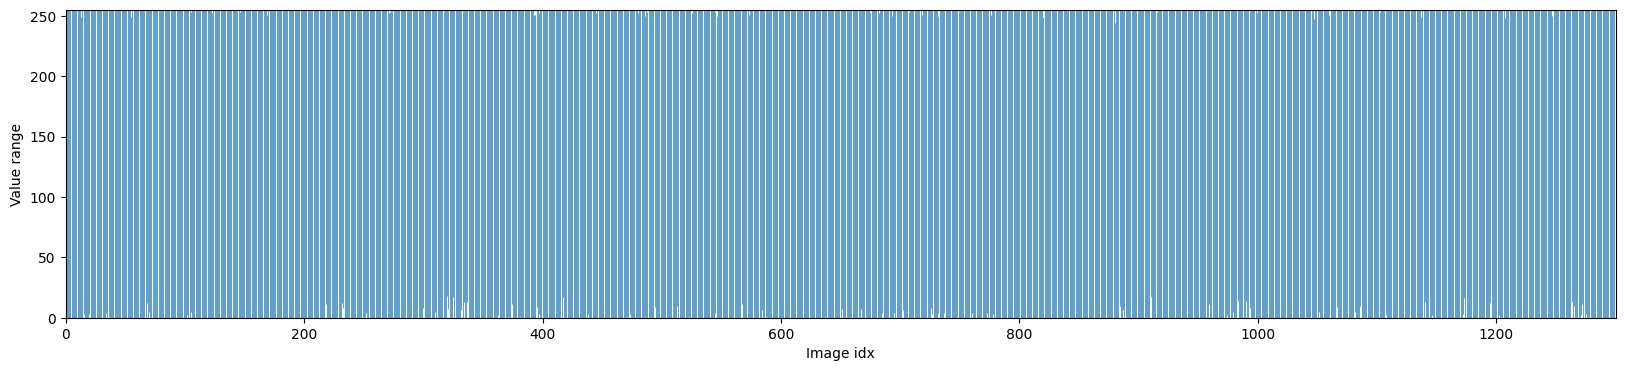

In [93]:
# Check 2: img stats
data_dir = Path("data/raw/agri_data/data")
img_paths = list(data_dir.glob("*.jpeg"))
img_shapes = set()
img_dtypes = set()
img_mins = []
img_maxs = []
for img_path in img_paths:
    img = np.asarray(Image.open(img_path))
    img_shapes.add(img.shape)
    img_dtypes.add(img.dtype)
    img_mins.append(img.min())
    img_maxs.append(img.max())

print(f"Image shapes found: {img_shapes}")
print(f"Image dtypes found: {img_dtypes}")
print(f"Value min: {min(img_mins)}; value max: {max(img_maxs)}")

fig = plt.figure(figsize=(20,4))
n_imgs = len(img_paths)
plt.vlines(x=range(n_imgs),
           ymin=img_mins,
           ymax=img_maxs,
           linewidth=0.5)
plt.xlim(0, n_imgs)
plt.ylim(min(img_mins), max(img_maxs))
plt.xlabel("Image idx")
plt.ylabel("Value range");


Bbox global min vals (x_c, y_c, w, h):
 [0.03418  0.038086 0.041016 0.037109]
Bbox global max vals (x_c, y_c, w, h):
 [0.975586 0.96582  0.998047 0.998047]
Bbox global xmin: 0.0019524999999999681
Bbox global ymin: 0.0019524999999999681
Bbox global xmax: 1.0000005
Bbox global ymax: 1.0000005
Counts per class: {0: 1212, 1: 860}


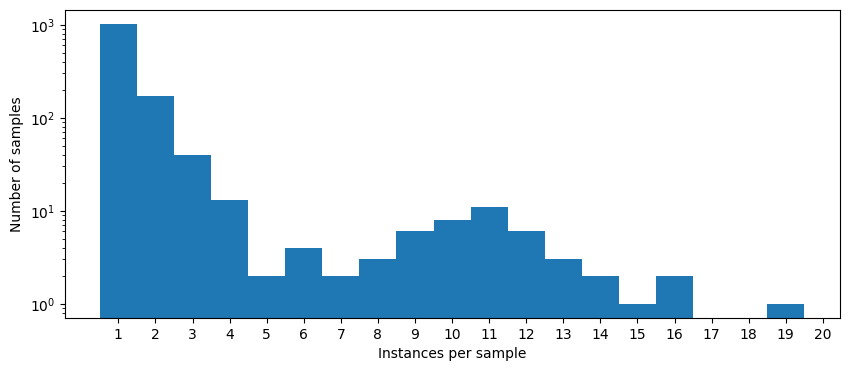

In [22]:
# Check 3: bbox + labels
def get_lbl_arrays(lbl_path):
    """ 
    Get class (int) + bbox (float) arrays from txt-label file
    """
    lbl_data = Path(lbl_path).read_text().split()
    
    if len(lbl_data) % 5 != 0:
        raise ValueError(f"Inconsistent label format for '{lbl_path}'")
    
    lbl_arr = np.array(lbl_data, dtype=np.float64).reshape(-1, 5)
    classes = lbl_arr[:, :1].astype(int)
    bbxs = lbl_arr[:, 1:]
    
    return classes, bbxs


data_dir = Path("data/raw/agri_data/data")
lbl_paths = list(data_dir.glob("*.txt"))

all_classes = []
all_bbxs = []
instances_per_sample = []


for lbl_path in lbl_paths:
    classes, bbxs = get_lbl_arrays(lbl_path)

    all_classes.append(classes)
    all_bbxs.append(bbxs)
    instances_per_sample.append(len(classes))

all_classes = np.concatenate(all_classes, axis=0)  
all_bbxs = np.concatenate(all_bbxs, axis=0)        
instances_per_sample = np.array(instances_per_sample)

x_c, y_c, w, h = all_bbxs[:, 0], all_bbxs[:, 1], all_bbxs[:, 2], all_bbxs[:, 3]
x_mins, x_maxs = x_c - w / 2, x_c + w / 2
y_mins, y_maxs = y_c - h / 2, y_c + h / 2


print(f"Bbox global min vals (x_c, y_c, w, h):\n {all_bbxs.min(axis=0)}")
print(f"Bbox global max vals (x_c, y_c, w, h):\n {all_bbxs.max(axis=0)}")
print(f"Bbox global xmin: {min(x_mins)}")
print(f"Bbox global ymin: {min(y_mins)}")
print(f"Bbox global xmax: {max(x_maxs)}")   
print(f"Bbox global ymax: {max(y_maxs)}") 

unique, counts = np.unique(all_classes, return_counts=True)
class_counts = dict(zip(unique.tolist(), counts.tolist()))
print(f"Counts per class: {class_counts}")

fig = plt.figure(figsize=(10,4))
plt.hist(x=instances_per_sample, 
         bins=range(1, instances_per_sample.max() + 2), 
         align="left",
         log=True)
plt.xlabel("Instances per sample")
plt.ylabel("Number of samples")
plt.xticks(range(1, instances_per_sample.max() + 2))
plt.show()

### 1.3 Inspect data visually

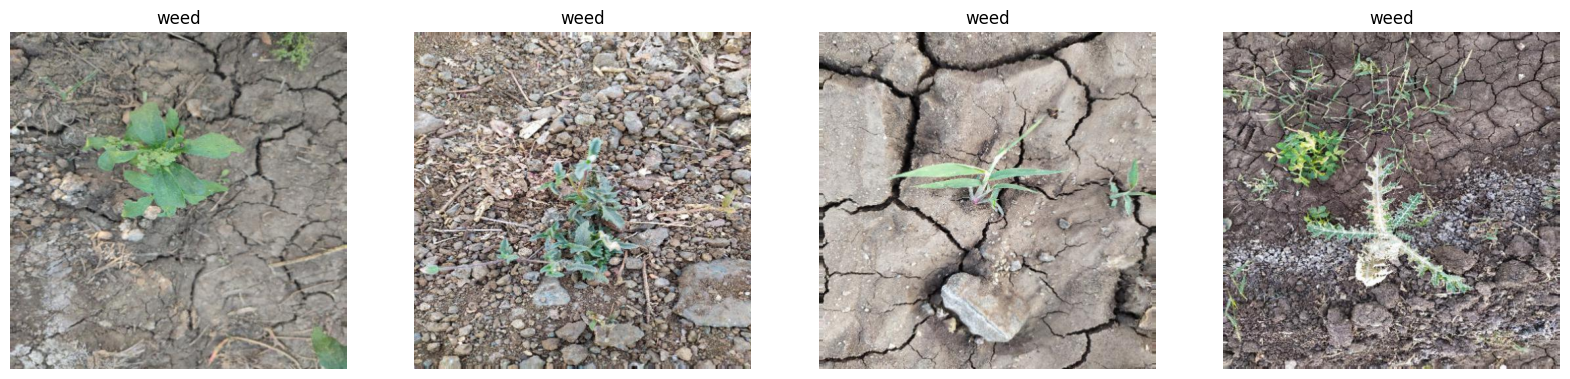

In [106]:
def inspect_rnd_sample(k=4):
    """
    Visualize k random data-label pairs
    """
    
    # Get random image path
    data_dir = Path("data/raw/agri_data/data")
    img_paths = list(data_dir.glob("*.jpeg"))
    rnd_img_paths = random.sample(img_paths, k)

    # Get class mapping
    classes_path = Path("data/raw/classes.txt")
    classes = open(classes_path, "r").read().split()
    idx_to_class = {i: c for i,c in enumerate(classes)}
 
    _, axs = plt.subplots(1,k,figsize=(5*k,5))

    for img_path, ax in zip(rnd_img_paths, axs):
        # Get label path
        img_id = img_path.stem
        lbl_path = data_dir / (img_id +".txt")

        # Get class label idx
        class_idx = int(open(lbl_path, "r").read()[0])
        class_label = idx_to_class[class_idx]         

        # Show image
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(class_label)
        ax.axis("off")

inspect_rnd_sample()

### 1.4 Preprocess data

In [39]:
from src.data import create_data_splits

create_data_splits()

## 2. Training

### 2.1 Create YOLO data yaml

In [19]:
from src.utils import write_yolo_yaml

write_yolo_yaml()

[INFO] YOLO data config written to 'configs/yolo.yaml'


### 2.2 Load model

In [23]:
from src.model import load_model

pretrained_weights = "yolov8n.pt"

model = load_model(weights=pretrained_weights)

### 2.3 Run training

In [22]:
from src.utils import load_config
from src.model import train

config = load_config()

train(model=model,
      config=config)

Ultralytics 8.4.66  Python-3.13.5 torch-2.12.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=configs/yolo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=32, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100